<a href="https://colab.research.google.com/github/neerajkiet1-pixel/EPIDEMICS/blob/main/Neeraj_kumar_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 EPIDEMIC SPREAD OVER N WEEKS  -  Cayley-Hamilton method

Transition matrix A (columns = from S, I, R):
 [[0.8  0.   0.05]
 [0.2  0.6  0.  ]
 [0.   0.4  0.95]]

Characteristic equation:  L^3 + (-2.35000) L^2 + (1.81000) L + (-0.46000) = 0
Eigenvalues: [0.675+0.06614j 0.675-0.06614j 1.   +0.j     ]
Cayley-Hamilton:  A^3 = 2.35000 A^2 + -1.81000 A + 0.46000 I

A^52 = c0 I + c1 A + c2 A^2  with
  c0=4.181818e+00, c1=-1.227273e+01, c2=9.090909e+00

A^52 (Cayley-Hamilton):
 [[0.18182 0.18182 0.18182]
 [0.09091 0.09091 0.09091]
 [0.72727 0.72727 0.72727]]

Max |CH - numpy.matrix_power| = 1.81e-13   PASS
Column sums of A^n (should be 1): [1. 1. 1.]
Time per A^52: Cayley-Hamilton 443.5 us | naive repeated multiply 100.3 us

Max difference CH-simulation vs iterative: 1.23e-13

 Week  Susceptible   Infected  Recovered
    0       0.9900     0.0100     0.0000
    4       0.4187     0.2794     0.3019
    8       0.2383     0.1683     0.5934
   12       0.1933     0.1127     0.6939
   16       0.18

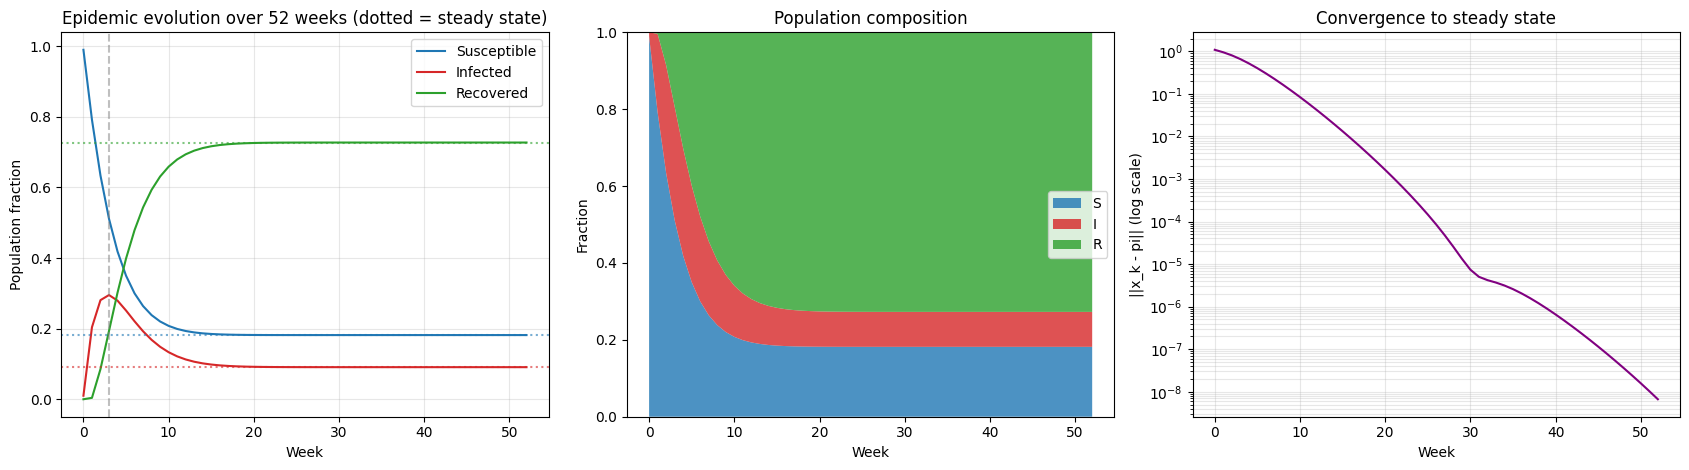

In [1]:
"""
Epidemic Spread Over N Weeks (SIR as a Markov chain) using Cayley-Hamilton
Needs: numpy, matplotlib
"""
import time
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)

# ================= PARAMETERS (edit these) =================
beta  = 0.20    # weekly infection probability (S -> I)
gamma = 0.40    # weekly recovery probability  (I -> R)
omega = 0.05    # weekly immunity-waning prob. (R -> S)
S0, I0 = 0.99, 0.01
weeks = 52
# ===========================================================

R0 = round(1 - S0 - I0, 10)
assert R0 >= 0, "S0 + I0 must be <= 1"
x0 = np.array([S0, I0, R0])


# ---------------- MODEL ----------------
def build_matrix(beta, gamma, omega):
    """Column-stochastic matrix; state order [S, I, R]; x_{k+1} = A x_k."""
    A = np.array([
        [1 - beta, 0.0,       omega],
        [beta,     1 - gamma, 0.0],
        [0.0,      gamma,     1 - omega],
    ])
    assert np.allclose(A.sum(axis=0), 1.0), "Columns must sum to 1"
    assert (A >= 0).all(), "Probabilities must be in [0,1]"
    return A


# ---------------- CAYLEY-HAMILTON ----------------
def char_poly(A):
    """[1, a1, a2, a3] for lambda^3 + a1 l^2 + a2 l + a3."""
    return np.poly(A)

def polymulmod(p, q, a):
    """Multiply polynomials (coeffs low->high, length 3) and reduce
    using x^3 = -a1 x^2 - a2 x - a3."""
    a1, a2, a3 = a
    prod = np.convolve(p, q).astype(float)
    for d in (4, 3):
        c = prod[d]
        prod[d] = 0.0
        prod[d - 1] += -a1 * c
        prod[d - 2] += -a2 * c
        prod[d - 3] += -a3 * c
    return prod[:3]

def ch_coefficients(A, n):
    """c0, c1, c2 with A^n = c0 I + c1 A + c2 A^2 (x^n mod p(x))."""
    a = char_poly(A)[1:]
    result = np.array([1.0, 0.0, 0.0])
    base   = np.array([0.0, 1.0, 0.0])
    while n > 0:                      # binary exponentiation
        if n & 1:
            result = polymulmod(result, base, a)
        base = polymulmod(base, base, a)
        n >>= 1
    return result

def matrix_power_ch(A, n):
    c0, c1, c2 = ch_coefficients(A, n)
    return c0 * np.eye(3) + c1 * A + c2 * (A @ A)


# ---------------- STEADY STATE & SIMULATION ----------------
def steady_state_eig(A):
    vals, vecs = np.linalg.eig(A)
    i = np.argmin(np.abs(vals - 1))
    v = np.real(vecs[:, i])
    return v / v.sum()

def steady_state_closed_form(beta, gamma, omega):
    v = np.array([1 / beta, 1 / gamma, 1 / omega])
    return v / v.sum()

def simulate_ch(A, x0, weeks):
    return np.array([matrix_power_ch(A, k) @ x0 for k in range(weeks + 1)])

def simulate_iter(A, x0, weeks):
    xs = [x0]
    for _ in range(weeks):
        xs.append(A @ xs[-1])
    return np.array(xs)


# ================= RUN =================
print("=" * 62)
print(" EPIDEMIC SPREAD OVER N WEEKS  -  Cayley-Hamilton method")
print("=" * 62)

A = build_matrix(beta, gamma, omega)
print("\nTransition matrix A (columns = from S, I, R):\n", A)

a = char_poly(A)
eig = np.linalg.eigvals(A)
print(f"\nCharacteristic equation:  "
      f"L^3 + ({a[1]:.5f}) L^2 + ({a[2]:.5f}) L + ({a[3]:.5f}) = 0")
print("Eigenvalues:", np.round(eig, 5))
print(f"Cayley-Hamilton:  A^3 = {-a[1]:.5f} A^2 + {-a[2]:.5f} A + {-a[3]:.5f} I")

# ---- A^n via Cayley-Hamilton ----
c = ch_coefficients(A, weeks)
print(f"\nA^{weeks} = c0 I + c1 A + c2 A^2  with")
print(f"  c0={c[0]:.6e}, c1={c[1]:.6e}, c2={c[2]:.6e}")
An = matrix_power_ch(A, weeks)
print(f"\nA^{weeks} (Cayley-Hamilton):\n", An)

# ---- Verification ----
ref = np.linalg.matrix_power(A, weeks)
err = np.max(np.abs(An - ref))
print(f"\nMax |CH - numpy.matrix_power| = {err:.2e}   "
      f"{'PASS' if err < 1e-9 else 'CHECK'}")
print("Column sums of A^n (should be 1):", An.sum(axis=0))

# ---- Timing ----
N = 20000
t = time.perf_counter()
for _ in range(N):
    matrix_power_ch(A, weeks)
t_ch = (time.perf_counter() - t) / N
t = time.perf_counter()
for _ in range(N):
    M = np.eye(3)
    for _ in range(weeks):
        M = M @ A
t_naive = (time.perf_counter() - t) / N
print(f"Time per A^{weeks}: Cayley-Hamilton {t_ch*1e6:.1f} us | "
      f"naive repeated multiply {t_naive*1e6:.1f} us")

# ---- Evolution ----
xs    = simulate_ch(A, x0, weeks)
xs_it = simulate_iter(A, x0, weeks)
print(f"\nMax difference CH-simulation vs iterative: {np.max(np.abs(xs - xs_it)):.2e}")

print(f"\n{'Week':>5} {'Susceptible':>12} {'Infected':>10} {'Recovered':>10}")
step = max(1, weeks // 13)
rows = list(range(0, weeks + 1, step)) + ([weeks] if weeks % step else [])
for k in rows:
    print(f"{k:5d} {xs[k,0]:12.4f} {xs[k,1]:10.4f} {xs[k,2]:10.4f}")

peak = int(np.argmax(xs[:, 1]))
print(f"\nPeak infection: {xs[peak,1]*100:.2f}% at week {peak}")

# ---- Steady state ----
pi_eig = steady_state_eig(A)
pi_cf  = steady_state_closed_form(beta, gamma, omega)
pi_pow = matrix_power_ch(A, 10**6) @ x0
print("\nSTEADY STATE  (A pi = pi)")
print("  Eigenvector (lambda=1):     ", pi_eig)
print("  Closed form (1/b,1/g,1/w):  ", pi_cf)
print("  A^1,000,000 x0 (CH):        ", pi_pow)
print(f"  Check ||A pi - pi|| = {np.linalg.norm(A @ pi_eig - pi_eig):.2e}")

second = sorted(np.abs(eig), reverse=True)[1]
print(f"  Second-largest |lambda| = {second:.4f}  "
      f"-> error shrinks by this factor each week")
dist = np.linalg.norm(xs - pi_eig, axis=1)
near = np.where(dist < 1e-3)[0]
if len(near):
    print(f"  Within 0.001 of steady state after week {near[0]}")
else:
    print(f"  Not within 0.001 of steady state in {weeks} weeks")

# ---- Plots ----
wk = np.arange(weeks + 1)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))

ax[0].plot(wk, xs[:, 0], label="Susceptible", color="tab:blue")
ax[0].plot(wk, xs[:, 1], label="Infected",    color="tab:red")
ax[0].plot(wk, xs[:, 2], label="Recovered",   color="tab:green")
for j, col in enumerate(["tab:blue", "tab:red", "tab:green"]):
    ax[0].axhline(pi_eig[j], ls=":", color=col, alpha=0.6)
ax[0].axvline(peak, ls="--", color="gray", alpha=0.5)
ax[0].set(title=f"Epidemic evolution over {weeks} weeks (dotted = steady state)",
          xlabel="Week", ylabel="Population fraction")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].stackplot(wk, xs[:, 0], xs[:, 1], xs[:, 2], labels=["S", "I", "R"],
                colors=["tab:blue", "tab:red", "tab:green"], alpha=0.8)
ax[1].set(title="Population composition", xlabel="Week",
          ylabel="Fraction", ylim=(0, 1))
ax[1].legend(loc="center right")

ax[2].semilogy(wk, dist + 1e-16, color="purple")
ax[2].set(title="Convergence to steady state", xlabel="Week",
          ylabel="||x_k - pi|| (log scale)")
ax[2].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("epidemic_52_weeks.png", dpi=150)
print("\nPlot saved as epidemic_52_weeks.png")
plt.show()